In [27]:
import torch
import dnnlib 
import pickle
import matplotlib.pyplot as plt 
from einops import rearrange
from run_metrics import ExperimentRunner
import mylib


tag_to_title = {
    "base" : "No Push-Pull VF",
    "nolinear" : "PPVF with no linear features",
    "dout=din" : r"D$_\text{out}$ = D$_\text{in}$",
    "dout=1" : r"D$_\text{out} = 1$",
    "dout=din & nf=1 ": r"D$_\text{out}$ = D$_\text{in}$, N$_A = 1$",
    "dout=din & nf=8" : r"D$_\text{out}$ = D$_\text{in}$, N$_A = 8$",
    "dout=1 & nf=1" : r"D$_\text{out} = 1 $, N$_A = 1$",
    "dout=1 & nf=8" : r"D$_\text{out} = 1 $, N$_A = 8$",
}

def imshow(x: torch.Tensor, title=None):
    plt.imshow(rearrange(x, "(b1 b2) c h w -> (b1 h) (b2 w) c", b1=4))
    plt.xticks([])
    plt.yticks([])
    if title:
        plt.title(title)
    plt.show()


def plot_entropy():
    entropy = torch.stack(mylib.gvf.LOGGER["entropy"],dim=1).detach().cpu()
    max_entropy = mylib.gvf.LOGGER["max_entropy"][-1][-1].item()
    plt.scatter(torch.arange(0, entropy.shape[1]), entropy.mean(dim=0))
    plt.title("Average entropy across batch")
    plt.xlabel("step")
    plt.ylabel(r"$\mathbf{E}[\ H(attention)\ ]$")
    plt.axhline(max_entropy, label="max entropy", ls="--")
    plt.grid()  
    plt.ylim(bottom=0, top=max_entropy*1.1)
    plt.show()

def examples():
    key = list(globals()["d"].keys())[0]
    paths = globals()["d"][key].example_paths 
    from torchvision.io import decode_image
    return torch.stack([decode_image(path) for path in paths])

def run(tag, config=None):
    mylib.gvf.LOGGER = {}
    # Update config 
    if config: 
        runner.config.gvf_kwargs = config
    else:
        runner.config.gvf_kwargs = None
    # Generated images
    image_iter = runner.generate_images(seed=0, net=net, encoder=encoder)
    for generated in image_iter:
        pass
    # Save to dictionary 
    d[tag] = generated
    # Show results
    title = tag_to_title[tag] if tag in tag_to_title else tag
    imshow(generated.images, title)
    imshow(examples(), "Examples")
    imshow(d["base"], tag_to_title["base"])
    # Plot entropy
    if mylib.gvf.LOGGER:
        plot_entropy()
  

    

# Setup network and runner

In [2]:
paths = {
    "config"    : "configs/config_runner.py",
    "templates" : "data/images/examples",
    "out"       : None,
}

# Load main network.
net = "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-imagenet-64x64-cond-adm.pkl"
net, encoder = dnnlib.util.import_net_from_url(net)
net = net.to("cuda")
# Load Runner 
runner = ExperimentRunner(paths, num_images=4)
d = {}

# Generate baseline

[rank0]:[W1106 13:43:02.035275724 ProcessGroupNCCL.cpp:4715] [PG ID 0 PG GUID 0 Rank 0]  using GPU 0 as device used by this process is currently unknown. This can potentially cause a hang if this rank to GPU mapping is incorrect. You can pecify device_id in init_process_group() to force use of a particular device.


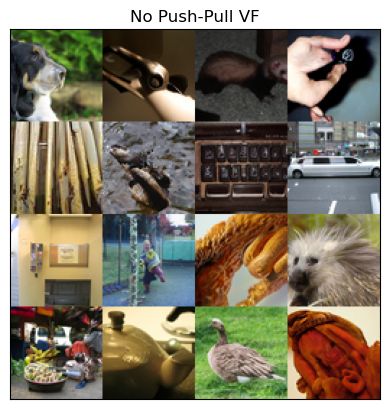

In [3]:
run("base")


# Examples

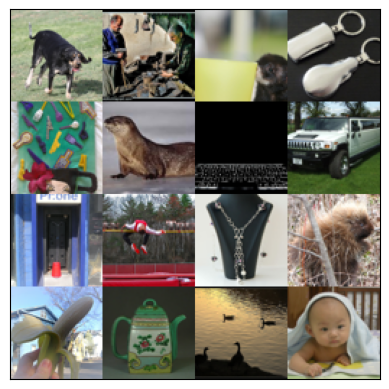

In [4]:
imshow(examples())

# PPVF No Linear

PushPullVF(
  (scale): 1.0 
  (pullbacks): 
    (0): PullbackNumericalDifferentiation
  (vf_inner): ScoreGatedDiracMixture(
      (score_fn): _score_single_component
      (channeled): False
      (shp_means): [16, 1, 4, 8, 8]
    (noise_gate): NoiseGate(
        (type_gate): heaviside
        (decimals): 4
        (nu): 5.5
        (noise_onset): inf
    )
  )
  (maps): ModuleList(
    (0): HFLatentMap(name : AutoencoderKL)
  )
)


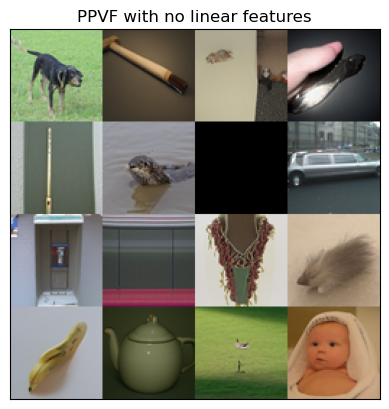

In [5]:
config = {
        "scale"         : 1.0,
        "maps"          : [
                            {"autoencoder" : "kl", "name" :"stabilityai/sd-turbo" },

                           ],
        "vector_field"  : {
            "noise_gate"    : { "type_gate" : "heaviside", "nu" : 5.5, },
            "noise"         : "edm",
            },
        "pullbacks"     : [
                            {"step_size_slope" : 1, "step_size_intercept": 0},

                           ],
    }


run("nolinear", config)

# D$_\text{out}$ =  D$_\text{in}$ , N$_\text{A} \ge 1$


PushPullVF(
  (scale): 1.0 
  (pullbacks): 
    (0): PullbackNumericalDifferentiation
    (1): pullback_linear
    (2): pullback_linear
  (vf_inner): ScoreGatedDiracMixture(
      (score_fn): _score_for_mixture_channeled
      (channeled): True
      (shp_means): [16, 1, 8, 256]
    (noise_gate): NoiseGate(
        (type_gate): heaviside
        (decimals): 4
        (nu): 5.5
        (noise_onset): inf
    )
    (attention): AttentionMixture()
  )
  (maps): ModuleList(
    (0): HFLatentMap(name : AutoencoderKL)
    (1): FlattenMap()
    (2): RandomLinearLatentMap(
      (matrix_map): MatrixLatentMapChanneled()
    )
  )
)


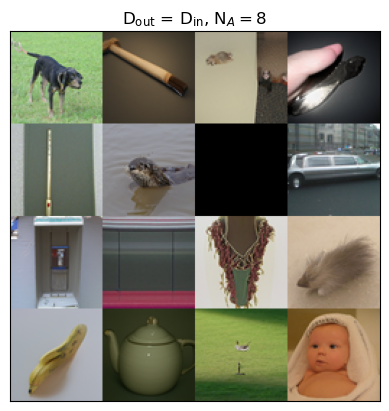

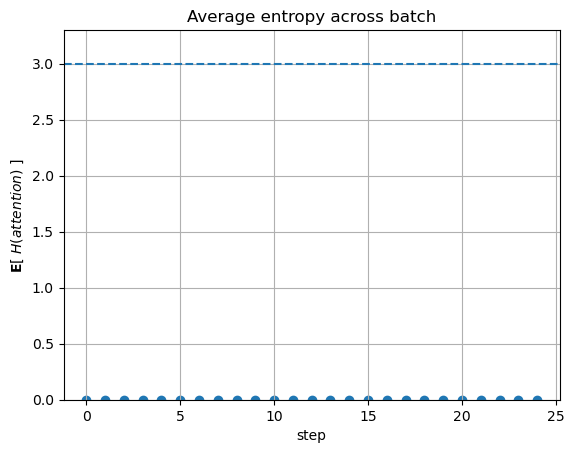

In [6]:
config = {
        "scale"         : 1.0,
        "maps"          : [
                            {"autoencoder" : "kl", "name" :"stabilityai/sd-turbo" },
                            "flatten",
                            {"seed": 0, "dim_in" : 256, "dim_out" : 256, "n_features" : 8},
                           ],
        "vector_field"  : {
            "noise_gate"    : { "type_gate" : "heaviside", "nu" : 5.5, },
            "noise"         : "edm",
            "kwargs"        : {"attention_kwargs" : {"normalize" : False, "pass_diff":True}},
            },
        "pullbacks"     : [
                            {"step_size_slope" : 1, "step_size_intercept": 0},
                            None,
                            None,
                           ],
    }

run("dout=din & nf=8", config)


# D$_\text{out}$ =  $1$ , N$_\text{A} \ge 1$


PushPullVF(
  (scale): 1.0 
  (pullbacks): 
    (0): PullbackNumericalDifferentiation
    (1): pullback_linear
    (2): pullback_linear
  (vf_inner): ScoreGatedDiracMixture(
      (score_fn): _score_for_mixture_channeled
      (channeled): True
      (shp_means): [16, 1, 8, 1]
    (noise_gate): NoiseGate(
        (type_gate): heaviside
        (decimals): 4
        (nu): 5.5
        (noise_onset): inf
    )
    (attention): AttentionMixture()
  )
  (maps): ModuleList(
    (0): HFLatentMap(name : AutoencoderKL)
    (1): FlattenMap()
    (2): RandomLinearLatentMap(
      (matrix_map): MatrixLatentMapChanneled()
    )
  )
)


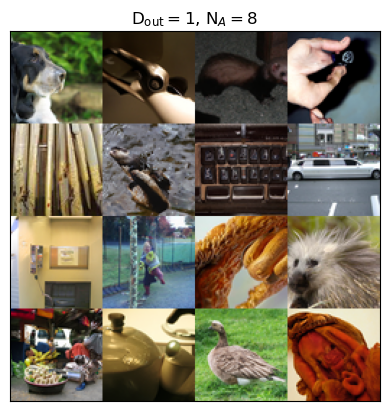

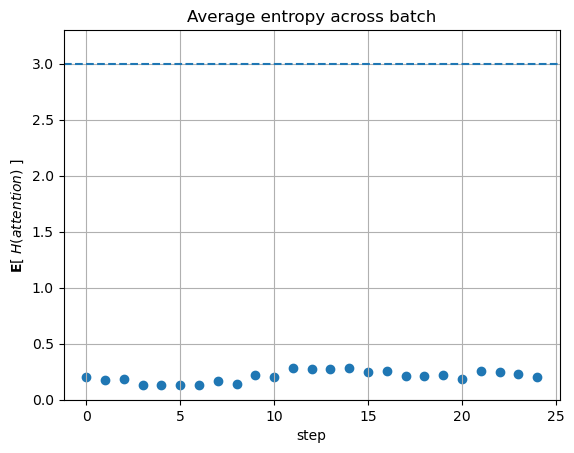

In [7]:
config = {
        "scale"         : 1.0,
        "maps"          : [
                            {"autoencoder" : "kl", "name" :"stabilityai/sd-turbo" },
                            "flatten",
                            {"seed": 0, "dim_in" : 256, "dim_out" : 1, "n_features" : 8},
                           ],
        "vector_field"  : {
            "noise_gate"    : { "type_gate" : "heaviside", "nu" : 5.5, },
            "noise"         : "edm",
            "kwargs"        : {"attention_kwargs" : {"normalize" : False, "pass_diff":True}},
            },
        "pullbacks"     : [
                            {"step_size_slope" : 1, "step_size_intercept": 0},
                            None,
                            None,
                           ],
    }


run("dout=1 & nf=8", config)


# Testing

In [11]:
print(d.keys())


dict_keys(['base', 'nolinear', 'dout=din & nf=8', 'dout=1 & nf=8'])


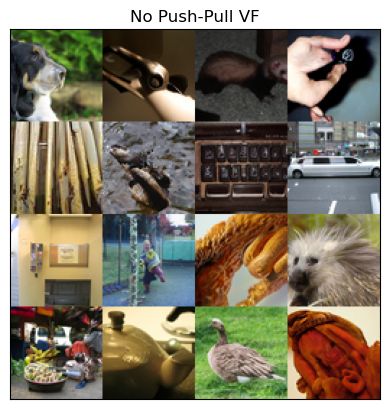

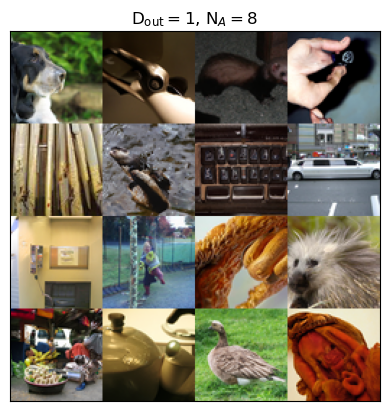

In [9]:
tag = "base"
imshow(d[tag].images, tag_to_title[tag])
tag = "dout=1 & nf=8"
imshow(d[tag].images, tag_to_title[tag])


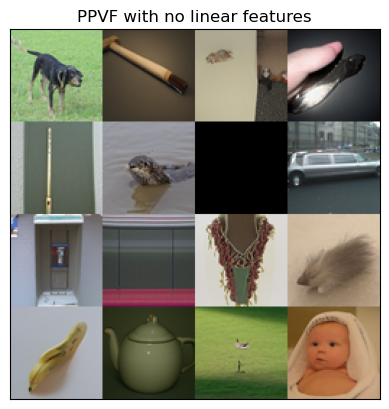

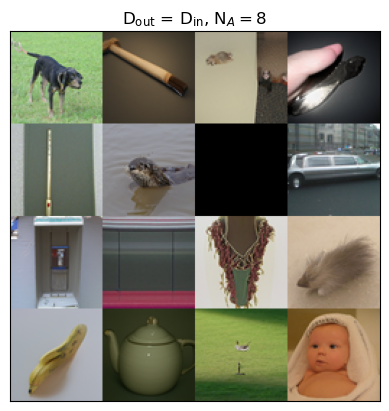

In [10]:
tag = "nolinear"
imshow(d[tag].images, tag_to_title[tag])
tag = "dout=din & nf=8"
imshow(d[tag].images, tag_to_title[tag])


PushPullVF(
  (scale): 1.0 
  (pullbacks): 
    (0): PullbackNumericalDifferentiation
    (1): pullback_linear
    (2): pullback_linear
  (vf_inner): ScoreGatedDiracMixture(
      (score_fn): _score_for_mixture_channeled
      (channeled): True
      (shp_means): [16, 1, 2, 128]
    (noise_gate): NoiseGate(
        (type_gate): heaviside
        (decimals): 4
        (nu): 5.5
        (noise_onset): inf
    )
    (attention): AttentionMixture()
  )
  (maps): ModuleList(
    (0): HFLatentMap(name : AutoencoderKL)
    (1): FlattenMap()
    (2): RandomLinearLatentMap(
      (matrix_map): MatrixLatentMapChanneled()
    )
  )
)


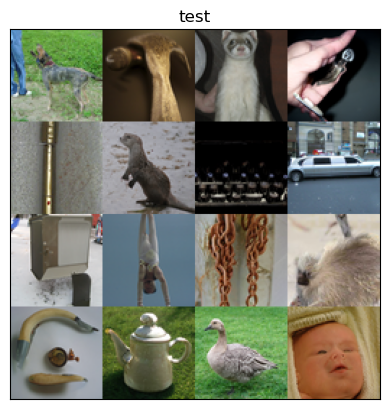

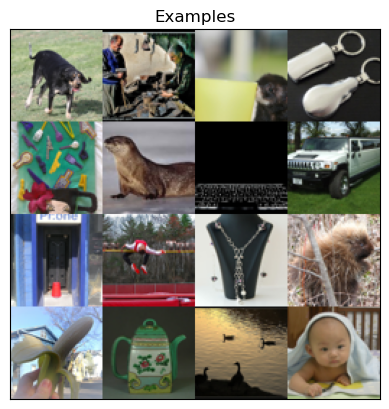

RuntimeError: Tensor type unknown to einops <class 'dnnlib.util.EasyDict'>

In [28]:
config = {
        "scale"         : 1.0,
        "maps"          : [
                            {"autoencoder" : "kl", "name" :"stabilityai/sd-turbo" },
                            "flatten",
                            {"seed": 0, "dim_in" : 256, "dim_out" : 128, "n_features" : 2},
                           ],
        "vector_field"  : {
            "noise_gate"    : { "type_gate" : "heaviside", "nu" : 5.5, },
            "noise"         : "edm",
            "kwargs"        : {"attention_kwargs" : {"T" : 1, "normalize" : False, "pass_diff":True}},
            },
        "pullbacks"     : [
                            {"step_size_slope" : 1, "step_size_intercept": 0},
                            None,
                            None,
                           ],
    }


run("test", config)
